In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "data/sample_xray.png"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
def color_balance(image):
    """Simple gray-world color balance for a BGR image."""
    result = image.astype(np.float32)
    channel_means = result.mean(axis=(0, 1))
    target_mean = channel_means.mean()
    scale = target_mean / (channel_means + 1e-6)
    return np.clip(result * scale, 0, 255).astype(np.uint8)


xray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if xray is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")


In [3]:
# 1. Histogram equalization
hist_equalized = cv2.equalizeHist(xray)

# 2. False-color heatmap
heatmap = cv2.applyColorMap(hist_equalized, cv2.COLORMAP_JET)

# 3. Mathematical color balance
balanced_heatmap = color_balance(heatmap)

# 4. Keep only the densest/brightest tissue
threshold_value = 200
_, dense_tissue_mask = cv2.threshold(
    hist_equalized, threshold_value, 255, cv2.THRESH_BINARY
)
dense_tissue = cv2.bitwise_and(
    hist_equalized, hist_equalized, mask=dense_tissue_mask
)

# 5. Log transformation to expand dark regions
c = 255 / np.log1p(np.max(xray))
log_image = c * np.log1p(xray.astype(np.float32))
log_image = np.uint8(np.clip(log_image, 0, 255))

# 6. Fractional power-law transformation, gamma < 1
# A value below 1 brightens midtones and reveals soft tissue.
gamma = 0.6
power_law = np.uint8(255 * (xray / 255.0) ** gamma)

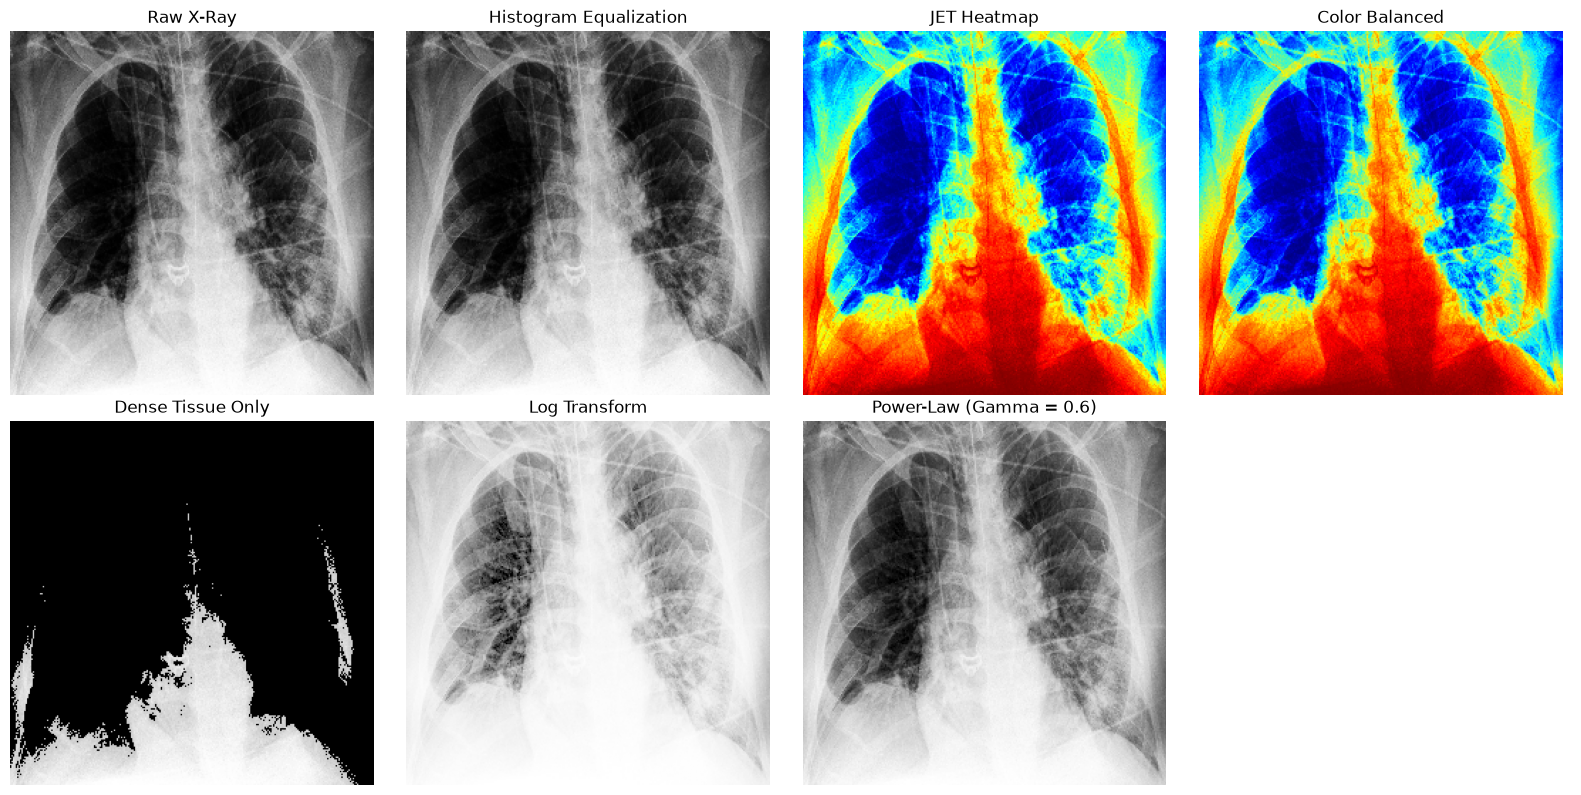

In [4]:
# Save important results
cv2.imwrite(f"{OUTPUT_DIR}/equalized_xray.png", hist_equalized)
cv2.imwrite(f"{OUTPUT_DIR}/false_color_heatmap.png", heatmap)
cv2.imwrite(f"{OUTPUT_DIR}/balanced_heatmap.png", balanced_heatmap)
cv2.imwrite(f"{OUTPUT_DIR}/dense_tissue_mask.png", dense_tissue_mask)
cv2.imwrite(f"{OUTPUT_DIR}/log_transformation.png", log_image)
cv2.imwrite(f"{OUTPUT_DIR}/power_law_transformation.png", power_law)

# Display all results for comparison
images = [
    xray, hist_equalized, heatmap, balanced_heatmap,
    dense_tissue, log_image, power_law
]
titles = [
    "Raw X-Ray", "Histogram Equalization", "JET Heatmap",
    "Color Balanced", "Dense Tissue Only", "Log Transform",
    "Power-Law (Gamma = 0.6)"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, image, title in zip(axes.ravel(), images, titles):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xray_comparison.png", dpi=200)
plt.show()